In [1]:
## This version of 1D greedy algorithm, the numerical quadrature used for assembling the linear system is consistent with 
## the quadrature used for the argmax subproblem.
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import time
import math 
import scipy 
from scipy.sparse import linalg
from pathlib import Path
if torch.cuda.is_available():  
    device = "cuda" 
else:  
    device = "cpu" 

pi = torch.tensor(np.pi,dtype=torch.float64)
torch.set_default_dtype(torch.float64)

import sys, os
sys.path.append(os.path.abspath("../../"))
from utils_quad_init import PiecewiseGQ1D_weights_points, PiecewiseGQ2D_weights_points, PiecewiseGQ3D_weights_points, initialize_w_b_uniform, initialize_w_b_sphere, initialize_w_b_petrushev
from utils_quad_init import model_tanh 


### different initialization schemes 

In [8]:
def minimize_linear_layer_explicit_assemble(model,target,weights, integration_points,solver="direct",activation = 'tanh'):
    """
    1. assemble matrix and rhs vector 
    2. solve the linear system and return the solution 
    """
    # Nx = 1024
    # order = 5
    # weights, integration_points = PiecewiseGQ1D_weights_points(-1,1,Nx,order) 
    # start_time = time.time()
    w = model.fc1.weight.data
    if activation == 'cos':
        basis_value_col = torch.cos(2*pi* (integration_points @ w.t()) ) # activation function dependent 
    elif activation == 'tanh':
        b = model.fc1.bias.data 
        basis_value_col = torch.tanh(integration_points @ w.t() + b) # activation function dependent 
    weighted_basis_value_col = basis_value_col * weights
    jac = weighted_basis_value_col.t() @ basis_value_col 
    # print("assembling the matrix time taken: ", time.time()-start_time) 
    rhs = weighted_basis_value_col.t() @ target(integration_points) 

    # print("using: ",solver, end = " ")
    if solver == "cg": 
        sol, exit_code = linalg.cg(np.array(jac.detach().cpu()),np.array(rhs.detach().cpu()),tol=1e-12)
        sol = torch.tensor(sol).view(1,-1)
    elif solver == "direct": 
#         sol = np.linalg.inv( np.array(jac.detach().cpu()) )@np.array(rhs.detach().cpu())
        sol = (torch.linalg.solve( jac.detach(), rhs.detach())).view(1,-1)
            # A x = b with A SPD

        ## regularizer 
        # lam = 1e-10
        # L = torch.linalg.cholesky(jac.detach() +  lam*torch.eye(jac.size(-1)) )                  # A = L L^T
        # sol = torch.cholesky_solve(rhs.detach(), L).view(1, -1)  # exact solve
        # Q, R = torch.linalg.qr(jac.detach(), mode="reduced")     # A = Q R
        # y = Q.mH @ rhs
        # sol = torch.linalg.solve_triangular(R, y,upper=True).view(1, -1)
    elif solver == "ls":
        sol = (torch.linalg.lstsq(jac.detach().cpu(),rhs.detach().cpu(),driver='gelsd',rcond = 1e-13).solution).view(1,-1)
        # sol = (torch.linalg.lstsq(jac.detach(),rhs.detach()).solution).view(1,-1) # gpu/cpu, driver = 'gels', cannot solve singular
    return sol 

def minimize_linear_layer_explicit_assemble_mat(model,target,weights, integration_points,solver="direct",activation = 'tanh'):
    """
    1. assemble matrix and rhs vector 
    2. solve the linear system and return the solution 
    """
    # Nx = 1024
    # order = 5
    # weights, integration_points = PiecewiseGQ1D_weights_points(-1,1,Nx,order) 
    # start_time = time.time()
    w = model.fc1.weight.data
    if activation == 'cos':
        basis_value_col = torch.cos(2*pi* (integration_points @ w.t()) ) # activation function dependent 
    elif activation == 'tanh':
        b = model.fc1.bias.data 
        basis_value_col = torch.tanh(integration_points @ w.t() + b) # activation function dependent 
    weighted_basis_value_col = basis_value_col * weights
    jac = weighted_basis_value_col.t() @ basis_value_col 
    # print("assembling the matrix time taken: ", time.time()-start_time) 
    rhs = weighted_basis_value_col.t() @ target(integration_points) 

    return jac, rhs 

def rescale_mat_rhs(A,f):
    c = 100.0
    for i in range(len(A)):
        ## change 
        max_a = abs(A[i,:]).max()
        max_b = A[i,:].max()
        if max_a != max_b: 
            ratio = -c/max_a
            A[i,:] = A[i,:]*ratio
            f[i] = f[i]*ratio
        else: 
            ratio = c/max_a
            A[i,:] = A[i,:]*ratio
            f[i] = f[i]*ratio
    return A,f 
def minimize_linear_layer_least_square(model,target,weights, integration_points,solver="direct",activation = 'tanh'):
    """
    1. assemble matrix and rhs vector 
    2. solve the linear system and return the solution 
    """
    # Nx = 1024
    # order = 5
    # weights, integration_points = PiecewiseGQ1D_weights_points(-1,1,Nx,order) 
    # start_time = time.time()
    w = model.fc1.weight.data
    if activation == 'cos':
        basis_value_col = torch.cos(2*pi* (integration_points @ w.t()) ) # activation function dependent 
    elif activation == 'tanh':
        b = model.fc1.bias.data 
        basis_value_col = torch.tanh(integration_points @ w.t() + b) # activation function dependent 
    weighted_basis_value_col = basis_value_col * (weights**0.5)
    jac = weighted_basis_value_col 
    # print("assembling the matrix time taken: ", time.time()-start_time) 
    rhs =  target(integration_points) * (weights**0.5)
    # jac, rhs = rescale_mat_rhs(jac,rhs) 
    # sol = (torch.linalg.lstsq(jac.detach().cpu(),rhs.detach().cpu(),driver='gelsd').solution).view(1,-1) 
    sol = scipy.linalg.lstsq(jac.cpu().numpy(),rhs.cpu().numpy())[0]
    sol = torch.from_numpy(sol).to(device).view(1,-1)
    return sol 

def linear_layer_least_square_mat(model,target,weights, integration_points,activation = 'tanh'):
    """
    1. assemble matrix and rhs vector 
    2. solve the linear system and return the solution 
    """
    w = model.fc1.weight.data
    if activation == 'cos':
        basis_value_col = torch.cos(2*pi* (integration_points @ w.t()) ) # activation function dependent 
    elif activation == 'tanh':
        b = model.fc1.bias.data 
        basis_value_col = torch.tanh(integration_points @ w.t() + b) # activation function dependent 
    weighted_basis_value_col = basis_value_col * (weights**0.5)
    jac = weighted_basis_value_col 
    # print("assembling the matrix time taken: ", time.time()-start_time) 
    rhs =  target(integration_points) * (weights**0.5)
    # jac, rhs = rescale_mat_rhs(jac,rhs) 
    # sol = (torch.linalg.lstsq(jac.detach().cpu(),rhs.detach().cpu(),driver='gelsd').solution).view(1,-1) 

    return jac 

def plot_err_loglog(neuron_num_arr,mean_err_l2_arr, legend1, title): 

    plt.figure(dpi = 200) 
    plt.plot(neuron_num_arr, mean_err_l2_arr, '.-', label = legend1) 

    # # Taking the logarithm of both M and errors
    # log_M = np.log(neuron_num_arr) 
    # log_errors = np.log(mean_err_l2_arr)
    # # Perform linear regression to find the slope and intercept of the line
    # slope, intercept = np.polyfit(log_M, log_errors, 1)
    # # Create a function for the line of best fit

    # def line_of_best_fit(x):
    #     return np.exp(intercept) * (x ** slope)
    # best_fit = line_of_best_fit(neuron_num_arr) 

    # plt.plot(neuron_num_arr, best_fit, label = "slope:{}".format(round(slope,2) ))
    plt.yscale('log') 
    plt.xscale('log') 
    plt.legend() 
    plt.ylabel("$L^2$ error")
    plt.xlabel("Number of neurons n")
    plt.title(title) 
    plt.show() 

### test quadrature method 

## Tanh activated NN
- predetermined neurons 
 

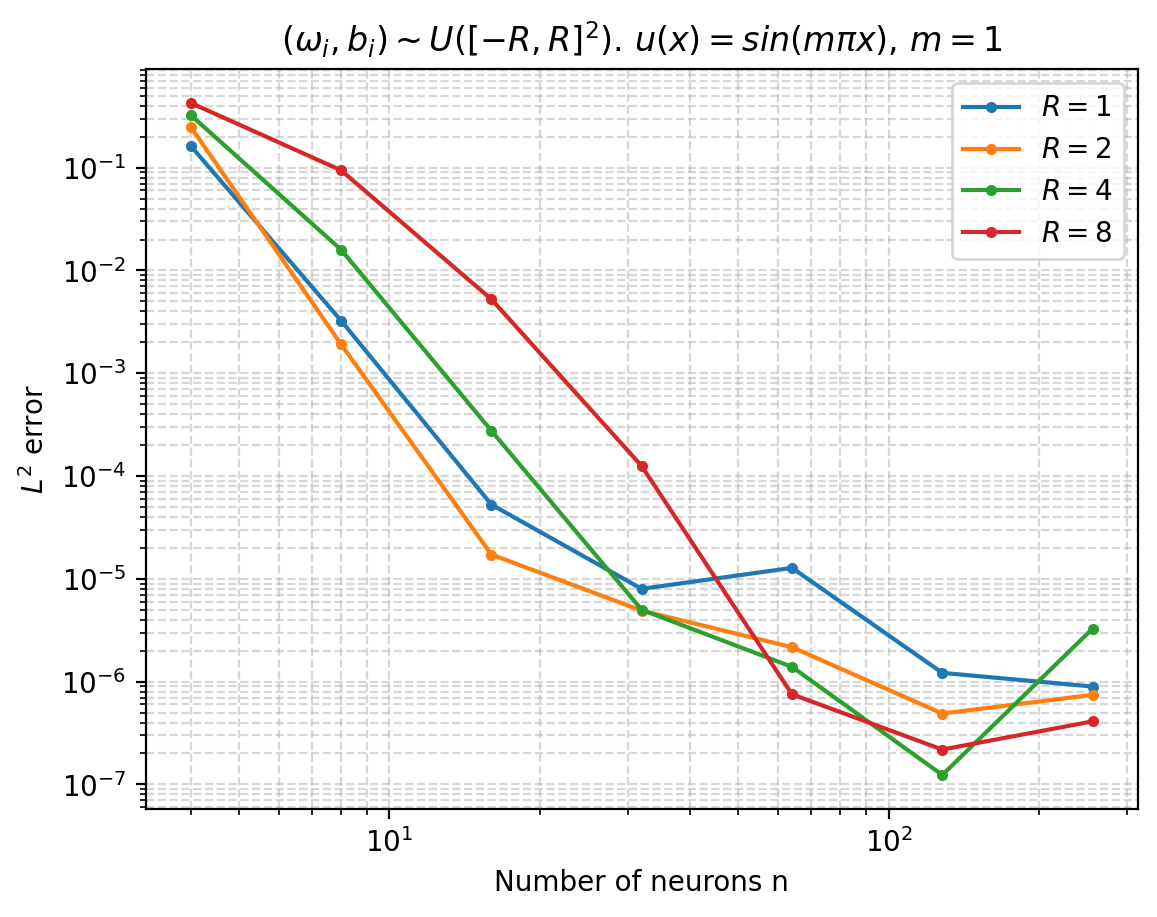

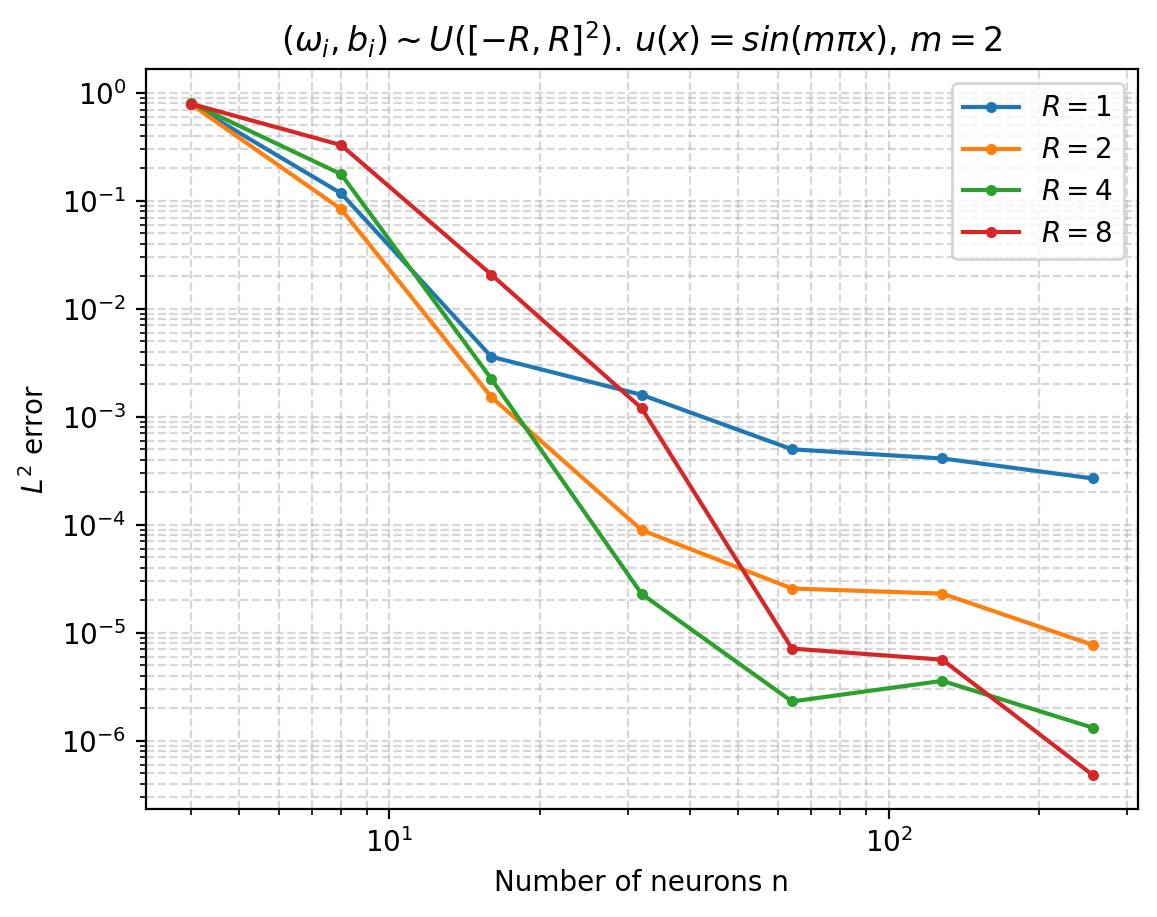

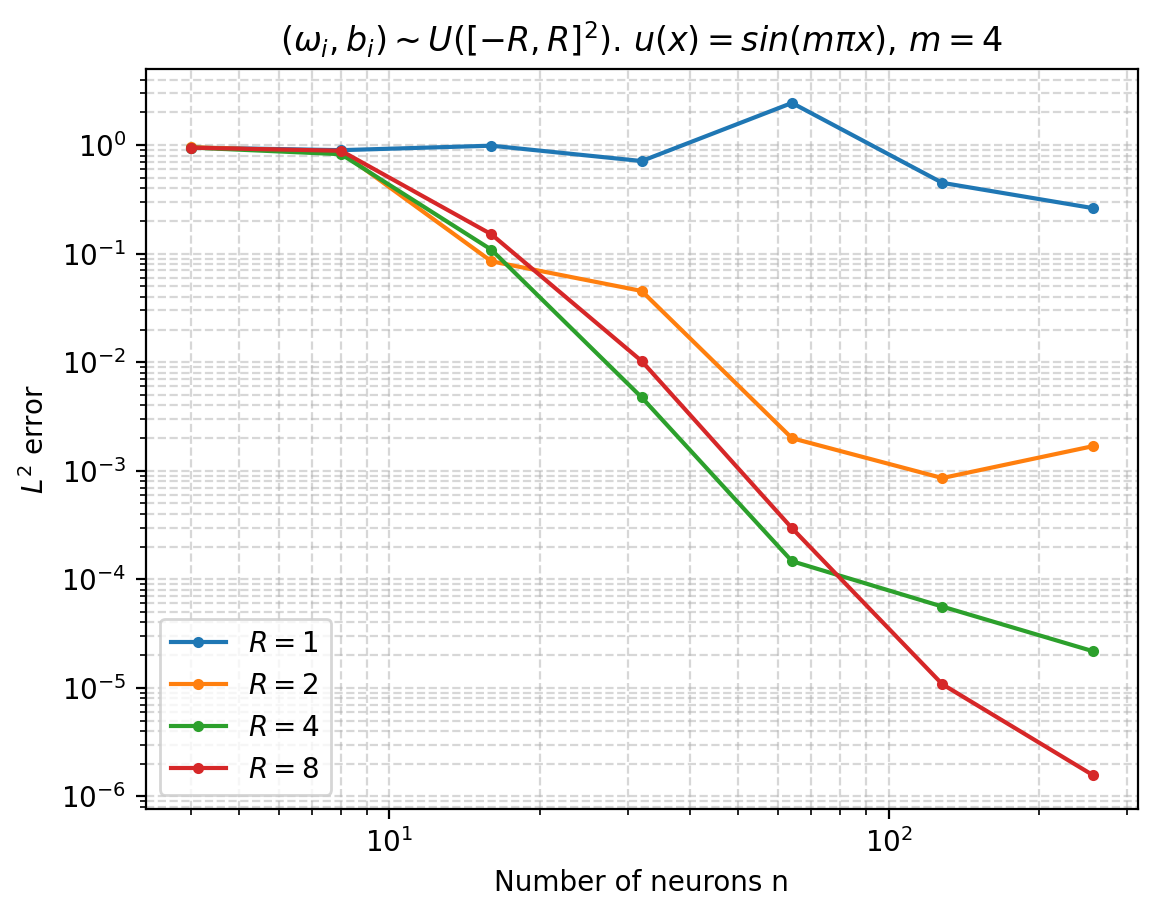

In [8]:
def run_exp(m): 
    
    Nx = 1024
    order = 5
    weights, integration_points = PiecewiseGQ1D_weights_points(-1,1,Nx = Nx, order = order)
    d = 1 
    save = True  
    foldername = 'data'
    petrushev = False 
    plt.figure(dpi = 200)
    def target(x):
        return  torch.sin(m * pi * x)
    for R_m in [1,2,4,8]: #  1,2,4,8,16,32  
        mean_err_l2_list = [] 
        neuron_num_arr= np.array([2**i for i in range(2,9)]) 
        for n in neuron_num_arr : 
            trial_num = 5
            err_l2_trial = torch.zeros(trial_num) 
            for trial in range(trial_num):
                my_model = model_tanh(1, n, 1).to(device) 
                if petrushev: 
                    my_model = initialize_w_b_petrushev(my_model,R_m)
                else: 
                    my_model = initialize_w_b_uniform(my_model, R_m)
                sol = minimize_linear_layer_explicit_assemble(my_model,target,weights, integration_points, solver="direct",activation='tanh')
                my_model.fc2.weight.data[0,:] = sol[:]

                with torch.no_grad(): 
                    nn_func_values = my_model(integration_points) 
                target_values = target(integration_points) 

                diff_sqrd = (nn_func_values - target_values)**2 
                err_l2 = ( weights.t() @ diff_sqrd )**0.5 
                err_l2_trial[trial] = err_l2 
            mean_err_l2 = torch.mean(err_l2_trial) 
            mean_err_l2_list.append(mean_err_l2) 
        mean_err_l2_arr = np.array(mean_err_l2_list) 
        if save: 
            data_uniform_distribution = np.concatenate([neuron_num_arr.reshape(-1,1),mean_err_l2_arr.reshape(-1,1)],axis = 1) 
            np.savetxt(f"{foldername}/ave_l2err_uniform_distribution_Rm_{R_m}_trials_{trial_num}.txt",data_uniform_distribution)
        legend1 =f"$R = {R_m}$"
        if petrushev: 
            title = f"Petrushev's scheme,$b \in (-R, R)$. $u(x) = sin(m \pi x)$, $m={m}$"
        else: 
            title = f"$(\omega_i,b_i) \sim U([-R,R]^{d+1})$. $u(x) = sin(m \pi x)$, $m={m}$"
        ## plot semi-log
        plt.plot(neuron_num_arr, mean_err_l2_arr, '.-', label = legend1)
        plt.yscale('log')
        plt.xscale('log')
        plt.legend()
        plt.ylabel("$L^2$ error")
        plt.xlabel("Number of neurons n")
        plt.title(title) 
    plt.grid(True, which="both", ls="--", alpha=0.5)
    if petrushev: 
        filename = f"{foldername}/petrushev_1d_sin_m_{m}_variational_R_m_{R_m}_gauss_{Nx}_{order}.png"
    else: 
        filename =  f"{foldername}/ELM_1d_sin_m_{m}_variational_R_m_{R_m}_gauss_{Nx}_{order}.png"
    if save: 
        plt.savefig(filename)
    else: 
        plt.show() 
for m in [1,2,4]:
    run_exp(m) 


### test least square solver for the variational method 

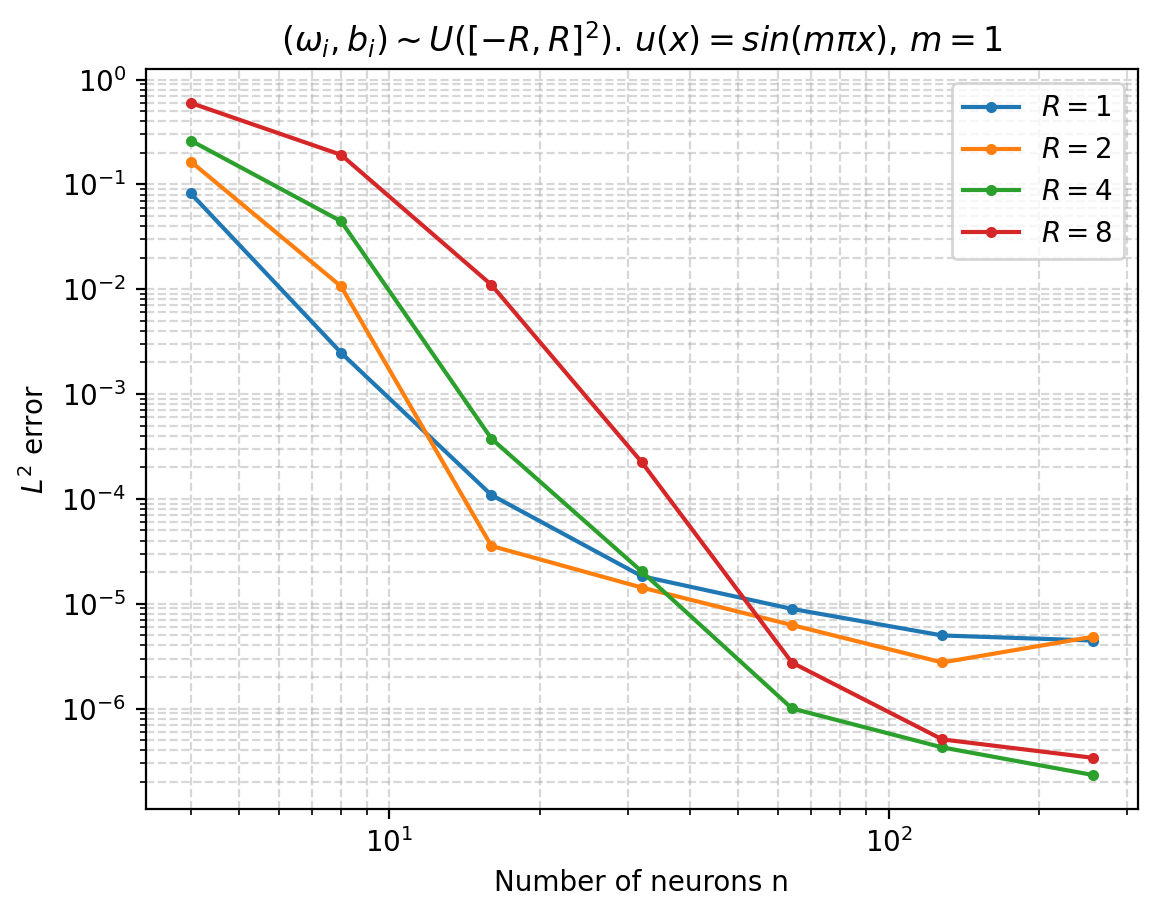

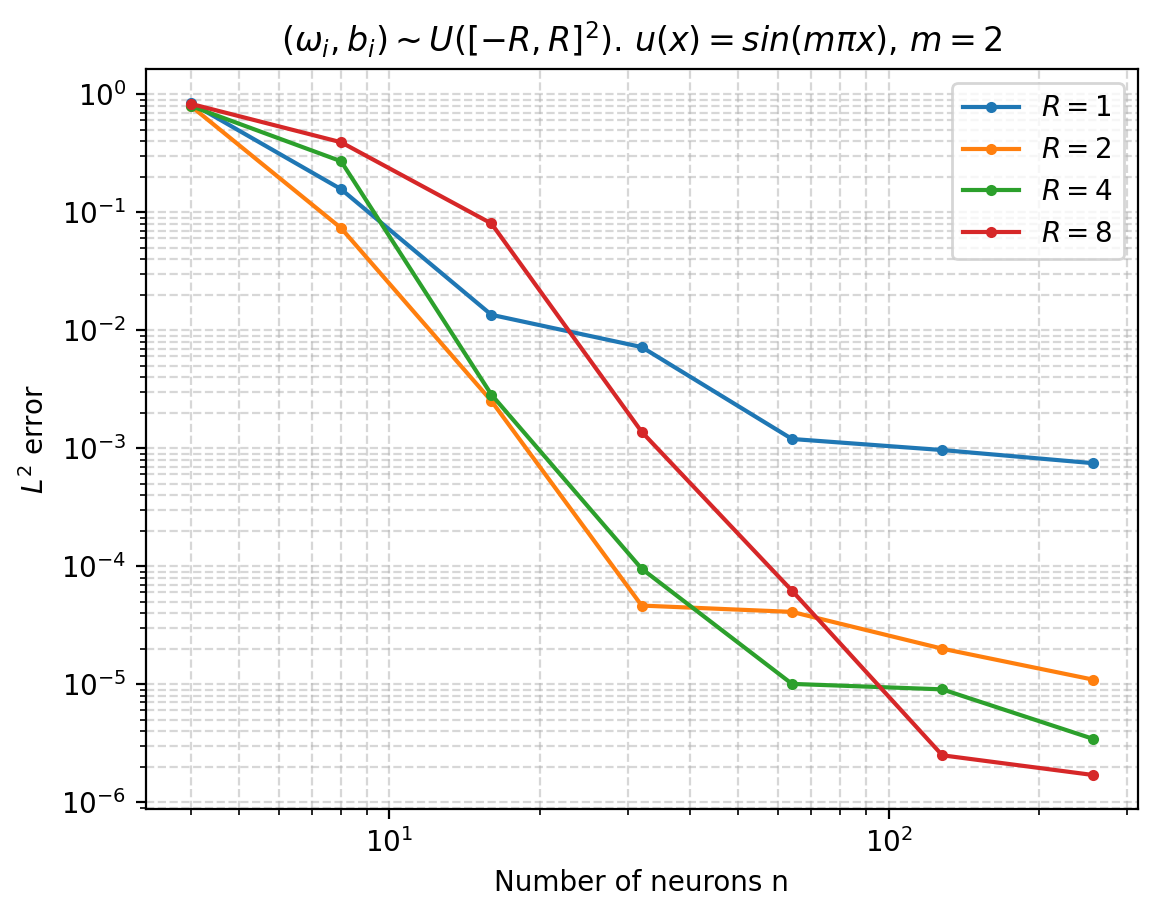

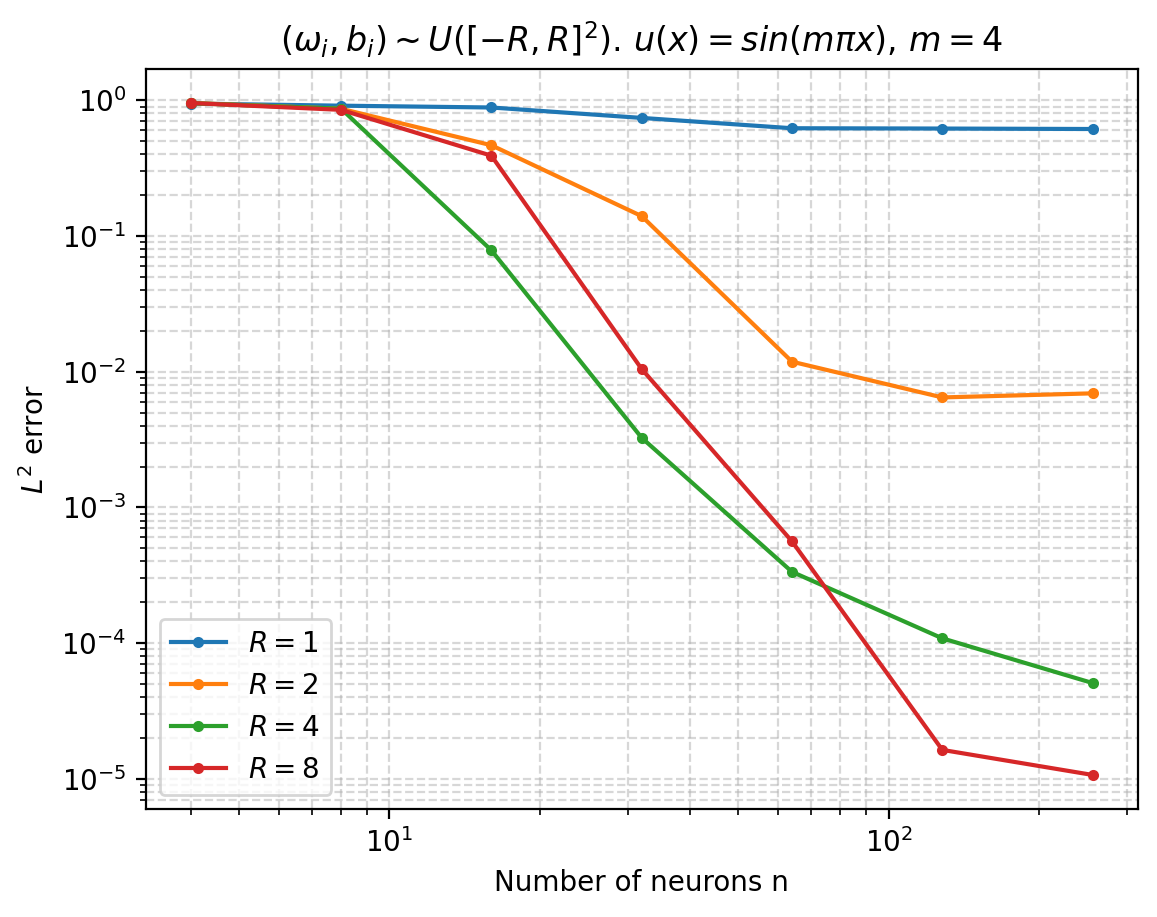

In [7]:
 

def run_exp(m): 
    
    Nx = 1024
    order = 5
    weights, integration_points = PiecewiseGQ1D_weights_points(-1,1,Nx = Nx, order = order)
    d = 1 
    save = True  
    foldername = 'data'
    petrushev = False 
    plt.figure(dpi = 200)
    def target(x):
        return  torch.sin(m * pi * x)
    for R_m in [1,2,4,8]: #  1,2,4,8,16,32  
        mean_err_l2_list = [] 
        neuron_num_arr= np.array([2**i for i in range(2,9)]) 
        for n in neuron_num_arr : 
            trial_num = 5
            err_l2_trial = torch.zeros(trial_num) 
            for trial in range(trial_num):
                my_model = model_tanh(1, n, 1).to(device) 
                if petrushev: 
                    my_model = initialize_w_b_petrushev(my_model,R_m)
                else: 
                    my_model = initialize_w_b_uniform(my_model, R_m)
                sol = minimize_linear_layer_explicit_assemble(my_model,target,weights, integration_points, solver="ls",activation='tanh')
                my_model.fc2.weight.data[0,:] = sol[:]

                with torch.no_grad(): 
                    nn_func_values = my_model(integration_points) 
                target_values = target(integration_points) 

                diff_sqrd = (nn_func_values - target_values)**2 
                err_l2 = ( weights.t() @ diff_sqrd )**0.5 
                err_l2_trial[trial] = err_l2 
            mean_err_l2 = torch.mean(err_l2_trial) 
            mean_err_l2_list.append(mean_err_l2) 
        mean_err_l2_arr = np.array(mean_err_l2_list) 
        if save: 
            data_uniform_distribution = np.concatenate([neuron_num_arr.reshape(-1,1),mean_err_l2_arr.reshape(-1,1)],axis = 1) 
            np.savetxt(f"{foldername}/ave_l2err_uniform_distribution_Rm_{R_m}_trials_{trial_num}.txt",data_uniform_distribution)
        legend1 =f"$R = {R_m}$"
        if petrushev: 
            title = f"Petrushev's scheme,$b \in (-R, R)$. $u(x) = sin(m \pi x)$, $m={m}$"
        else: 
            title = f"$(\omega_i,b_i) \sim U([-R,R]^{d+1})$. $u(x) = sin(m \pi x)$, $m={m}$"
        ## plot semi-log
        plt.plot(neuron_num_arr, mean_err_l2_arr, '.-', label = legend1)
        plt.yscale('log')
        plt.xscale('log')
        plt.legend()
        plt.ylabel("$L^2$ error")
        plt.xlabel("Number of neurons n")
        plt.title(title) 
    plt.grid(True, which="both", ls="--", alpha=0.5)
    if petrushev: 
        filename = f"{foldername}/petrushev_1d_sin_m_{m}_variational_R_m_{R_m}_gauss_{Nx}_{order}.png"
    else: 
        filename =  f"{foldername}/ELM_1d_sin_m_{m}_variational_R_m_{R_m}_gauss_{Nx}_{order}.png"
    if save: 
        plt.savefig(filename)
    else: 
        plt.show() 
for m in [1,2,4]:
    run_exp(m) 


In [9]:
def target(x):
    return  torch.sin(pi * x)
for R_m in [2,4,8]: #  1,2,4,8,16,32  

    weights, integration_points = PiecewiseGQ1D_weights_points(-1,1,Nx = 1024, order = 20) 
    neuron_num_arr= np.array([2**i for i in range(1,9)]) 
    for n in neuron_num_arr : 
        print(n)
        my_model = model_tanh(1, n, 1).to(device) 
        # my_model = initialize_w_b_petrushev(my_model,R_m)
        my_model = initialize_w_b_uniform(my_model, R_m)
        mat = minimize_linear_layer_explicit_assemble_mat(my_model,target,weights, integration_points, solver="direct",activation='tanh')
        
        print("matrix condition number: ", np.linalg.cond(np.array(mat[0].detach().cpu())) ) 

2
matrix condition number:  4.289280703798069
4
matrix condition number:  76422.85333719736
8
matrix condition number:  17354241337489.043
16
matrix condition number:  1.2954353255155544e+16
32
matrix condition number:  1.581488917776031e+17
64
matrix condition number:  4.648407916761348e+17
128
matrix condition number:  2.998105249207759e+17
256
matrix condition number:  1.4779508314257848e+18
2
matrix condition number:  2.80120359842283
4
matrix condition number:  6221.788907371294
8
matrix condition number:  1628529439.9245746
16
matrix condition number:  3661785869743441.0
32
matrix condition number:  7911551618989408.0
64


/var/folders/45/p1_q2drx75983lk7ph_1gx6mhpr5_w/T/ipykernel_28505/1353554835.py:14: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  print("matrix condition number: ", np.linalg.cond(np.array(mat[0].detach().cpu())) )


matrix condition number:  4.857271329780746e+17
128
matrix condition number:  1.0430068636918616e+18
256
matrix condition number:  3.043314421554586e+18
2
matrix condition number:  7.974685014820732
4
matrix condition number:  79606.34721220288
8
matrix condition number:  18207674342127.246
16
matrix condition number:  6547453462798043.0
32
matrix condition number:  1.2593604133916262e+17
64
matrix condition number:  1.2927230969145078e+17
128
matrix condition number:  8.74387950514508e+17
256
matrix condition number:  3.496184172350246e+18


In [ ]:
for R_m in [2,4,8]: #  1,2,4,8,16,32  

    weights, integration_points = PiecewiseGQ2D_weights_points(Nx = 20, order = 5,l_point = (-1, -1),r_point= (1,1)) 
    neuron_num_arr= np.array([2**i for i in range(1,9)]) 
    for n in neuron_num_arr : 
        print(n)
        my_model = model_tanh(2, n, 1).to(device) 
        # my_model = initialize_w_b_petrushev(my_model,R_m)
        my_model = initialize_w_b_uniform(my_model, R_m)
        mat = minimize_linear_layer_explicit_assemble_mat(my_model,target,weights, integration_points, solver="direct",activation='tanh')
        
        print("matrix condition number: ", np.linalg.cond(np.array(mat[0].detach().cpu())) ) 

2
matrix condition number:  2794.585385929079
4
matrix condition number:  2794.585385929079
8
matrix condition number:  1504560.9842695307
16
matrix condition number:  106014471.84387426
32
matrix condition number:  223643380473.52087
64
matrix condition number:  8090162055739021.0
128
matrix condition number:  2.1853971329646794e+18
256
matrix condition number:  4.000474805363722e+19


/Users/xux0f/Desktop/github/RandomNeuralPapers2/code/utils_quad_init.py:345: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  theta = torch.tensor(theta).to(device)
/var/folders/45/p1_q2drx75983lk7ph_1gx6mhpr5_w/T/ipykernel_27477/649186919.py:11: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  print("matrix condition number: ", np.linalg.cond(np.array(mat[0].detach().cpu())) )


In [72]:
import scipy 
M = mat[0]
M = M.detach().cpu() 
#compute  largest eigenvalues 
w = scipy.linalg.eigh(M, eigvals_only=True)   # sorted ascending
lam_min, lam_max = w[0], w[-1]
cond = lam_max/lam_min 
print(cond)

-3975166425632007.5


### least square form

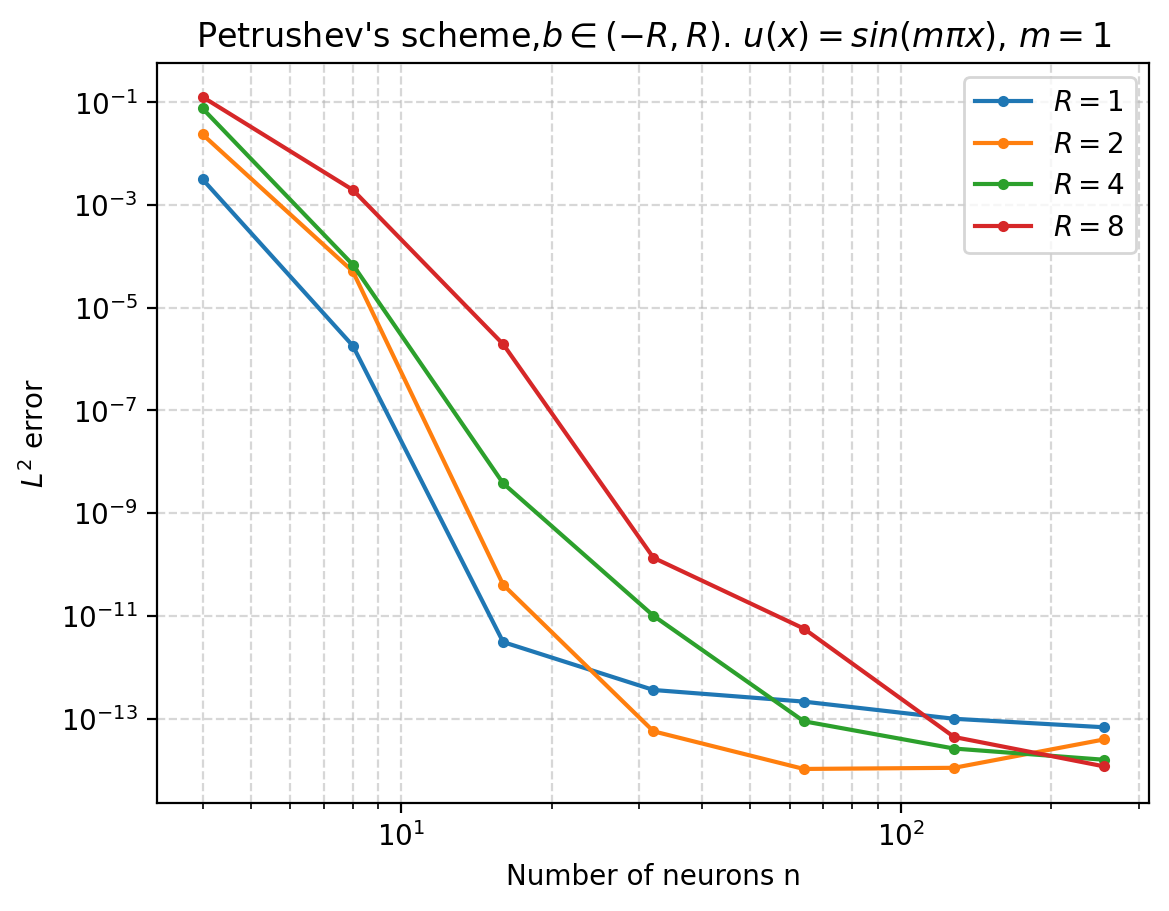

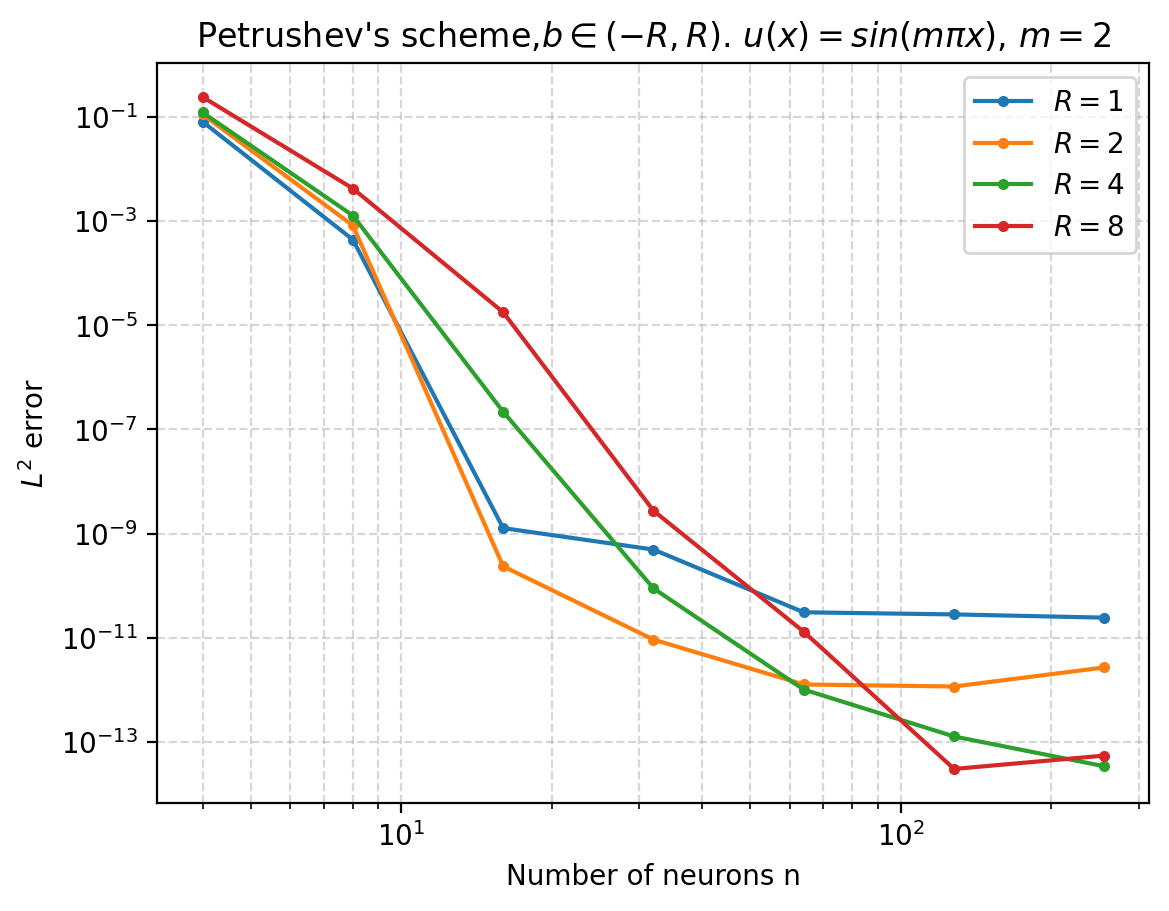

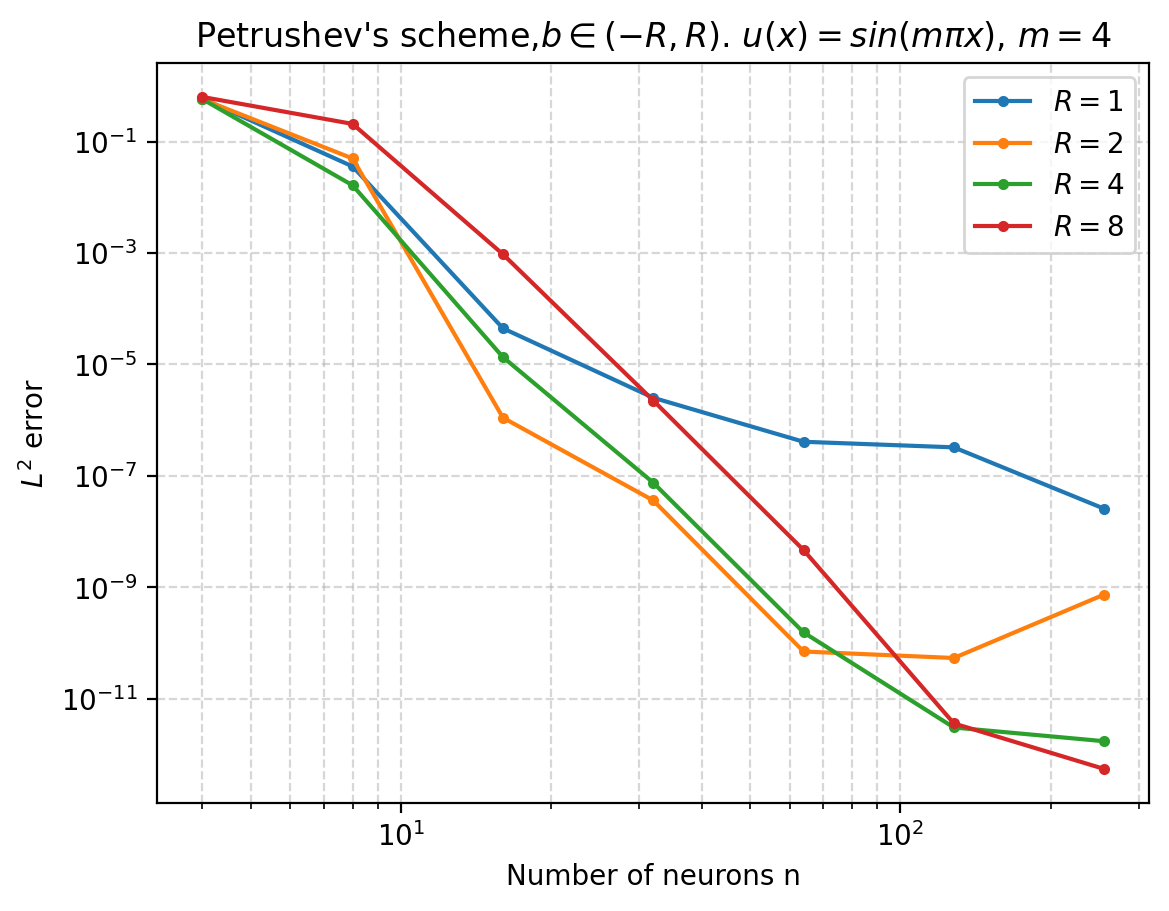

In [26]:
def run_exp2(m): 
    Nx = 1024
    order = 3 
    weights, integration_points = PiecewiseGQ1D_weights_points(0,1,Nx = Nx, order = order)
    save = False    
    plt.figure(dpi = 200)
    def target(x):
        return  torch.sin(m * pi * x)
    for R_m in [1,2,4,8]: #  1,2,4,8,16,32  
        mean_err_l2_list = [] 
        neuron_num_arr= np.array([2**i for i in range(2,9)]) 
        # neuron_num_arr= np.array([i for i in range(1,60,2)]) 
        for n in neuron_num_arr : 
            trial_num = 2 
            err_l2_trial = torch.zeros(trial_num) 
            for trial in range(trial_num):
                my_model = model_tanh(1, n, 1).to(device) 
                # my_model = initialize_w_b_petrushev(my_model,R_m)
                my_model = initialize_w_b_uniform(my_model, R_m)
                sol = minimize_linear_layer_least_square(my_model,target,weights, integration_points, solver="direct",activation='tanh')
                my_model.fc2.weight.data[0,:] = sol[:]

                with torch.no_grad(): 
                    nn_func_values = my_model(integration_points) 
                target_values = target(integration_points) 

                diff_sqrd = (nn_func_values - target_values)**2 
                err_l2 = ( weights.t() @ diff_sqrd )**0.5 
                err_l2_trial[trial] = err_l2 
            mean_err_l2 = torch.mean(err_l2_trial) 
            mean_err_l2_list.append(mean_err_l2) 
        mean_err_l2_arr = np.array(mean_err_l2_list) 
        if save: 
            data_uniform_distribution = np.concatenate([neuron_num_arr.reshape(-1,1),mean_err_l2_arr.reshape(-1,1)],axis = 1) 
            np.savetxt("ave_l2err_uniform_distribution_Rm_{}_trials_{}_ls_eqn.txt".format(R_m, trial_num),data_uniform_distribution)
        legend1 =f"$R = {R_m}$"
        title = f"Petrushev's scheme,$ b \in (-R, R)$. $u(x) = sin(m \pi x)$, $m={m}$"
        ## plot semi-log
        
        plt.plot(neuron_num_arr, mean_err_l2_arr, '.-', label = legend1)
        
        plt.yscale('log')
        plt.xscale('log')
        plt.legend()
        plt.ylabel("$L^2$ error")
        plt.xlabel("Number of neurons n")
        plt.title(title) 
    plt.grid(True, which="both", ls="--", alpha=0.5)
    filename = "petrushev_1d_sin_m_{}_variational_R_m_{}_gauss_{}_{}_ls_eqn.png".format(m,R_m,Nx,order)
    if save: 
        plt.savefig(filename)
    else: 
        plt.show() 
for m in [1,2,4]:
    run_exp2(m) 


### compute singular values of the matrix  

<Figure size 1280x960 with 0 Axes>

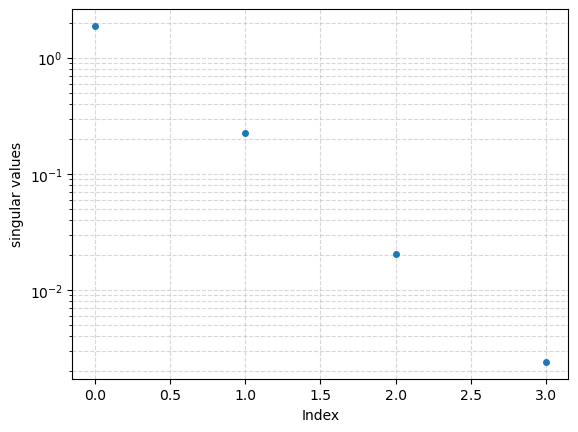

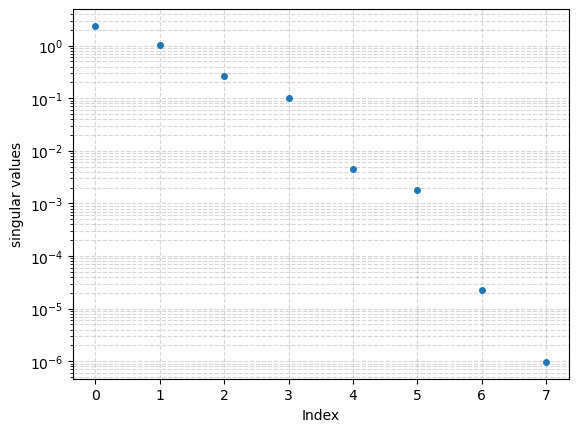

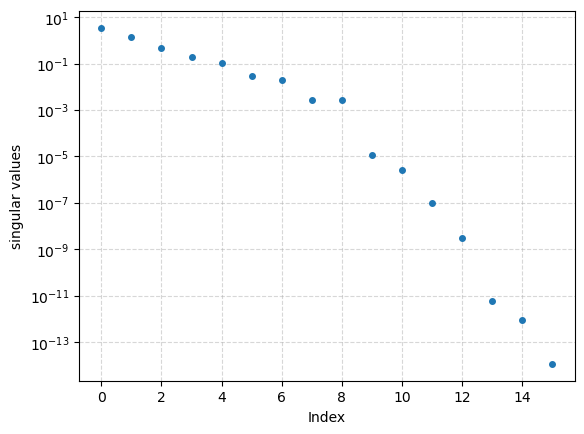

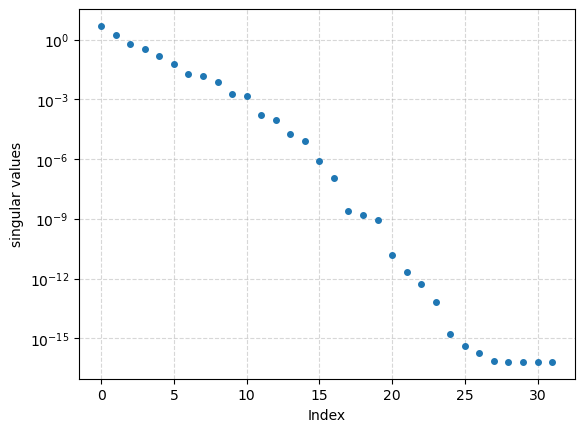

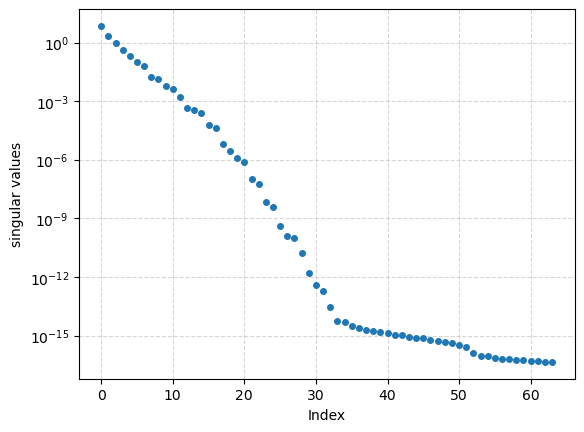

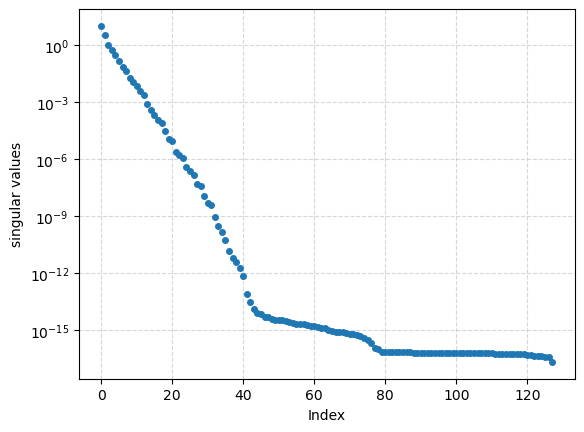

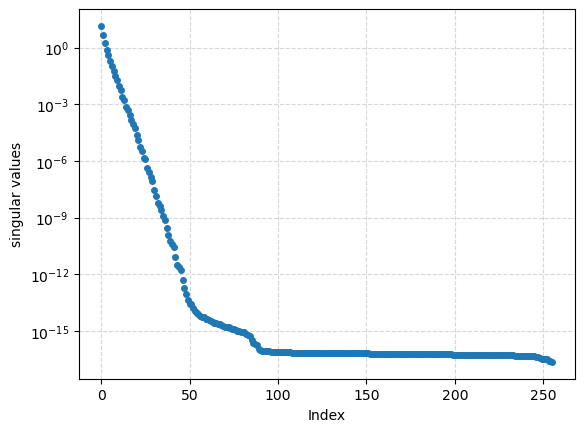

In [11]:
def compute_singular_values(m): 
    Nx = 1024
    order = 3 
    weights, integration_points = PiecewiseGQ1D_weights_points(0,1,Nx = Nx, order = order)
    save = False    
    plt.figure(dpi = 200)
    def target(x):
        return  torch.sin(m * pi * x)
    R_m = 8 
    mean_err_l2_list = [] 
    neuron_num_arr= np.array([2**i for i in range(2,9)]) 
    # neuron_num_arr= np.array([i for i in range(1,60,2)]) 
    for n in neuron_num_arr : 
        trial_num = 2 
        err_l2_trial = torch.zeros(trial_num) 
        for trial in range(trial_num):
            my_model = model_tanh(1, n, 1).to(device) 
            # my_model = initialize_w_b_petrushev(my_model,R_m)
            my_model = initialize_w_b_uniform(my_model, R_m)
            A = linear_layer_least_square_mat(my_model,target,weights, integration_points,activation='tanh')
            s = torch.linalg.svdvals(A)
        #plot the singular values 
        s_rel = s  # s / s[0]

        plt.figure()
        plt.semilogy(s_rel, 'o',markersize=4)
        # plt.plot(s, 'o', markersize=4)
        plt.xlabel('Index')
        plt.ylabel(r'singular values')
        plt.grid(True, which="both", ls="--", alpha=0.5)
        plt.show()
for m in [4]:
    compute_singular_values(m) 


## 2D RFM - Petrushev's scheme 

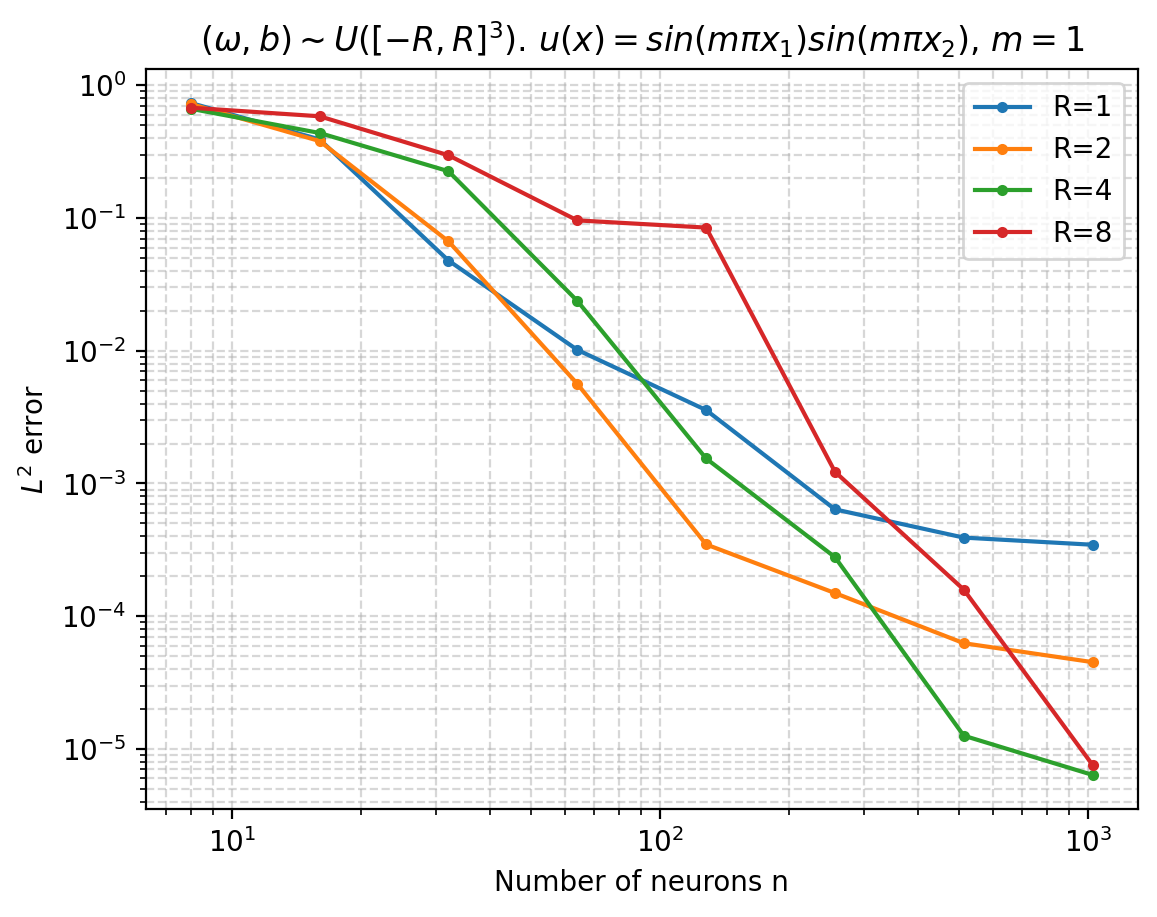

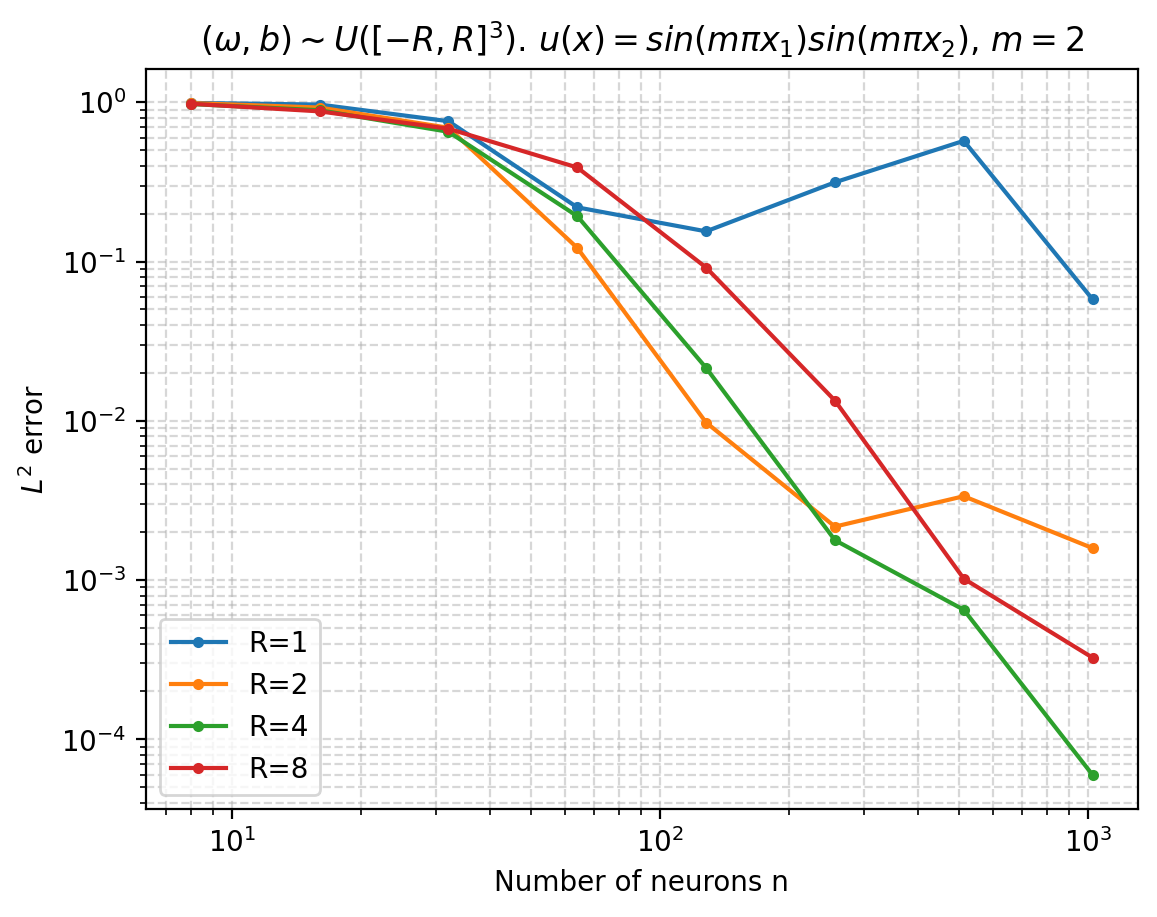

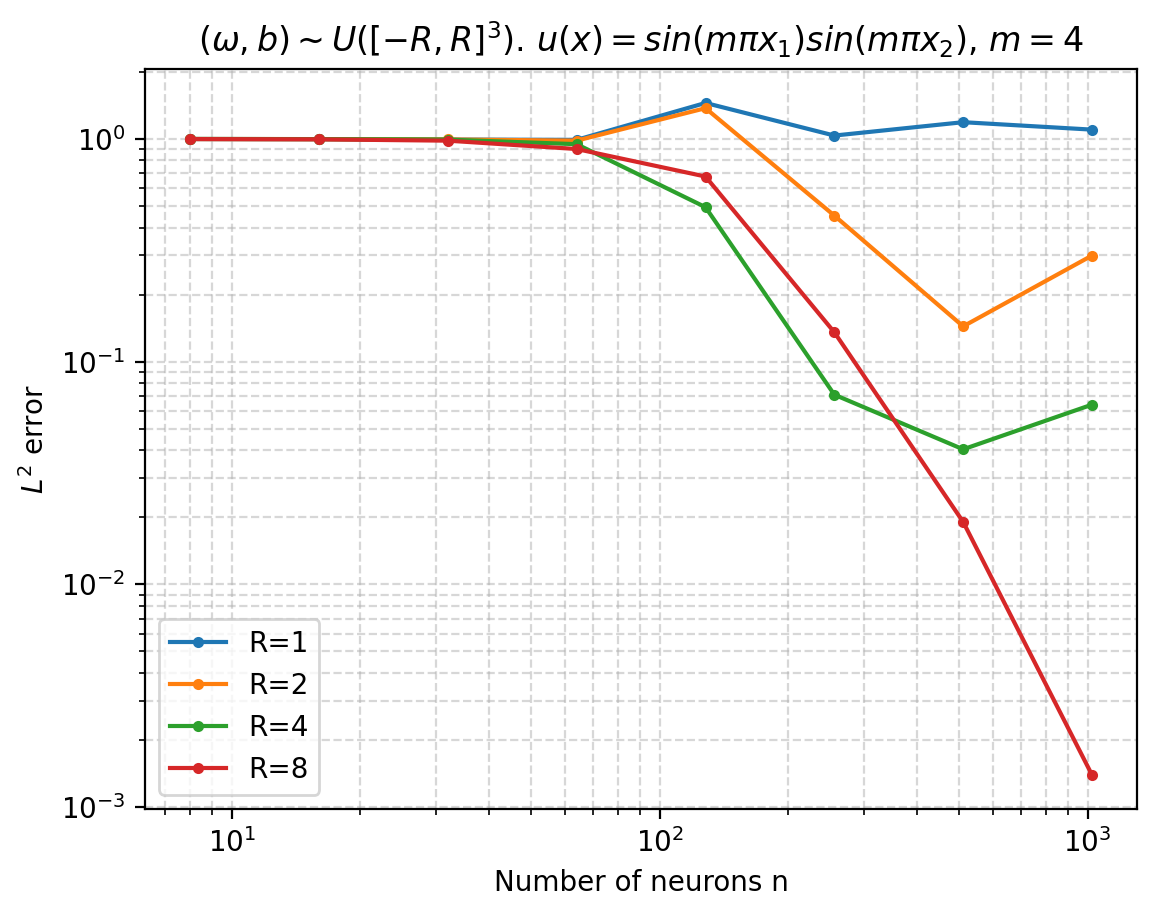

In [15]:
def run_experiment_2d(target,m1,m2): 

    def target(x): 
        return torch.sin(m1 * pi * x[:,0:1]) * torch.sin(m2 * pi * x[:,1:2])
    Nx = 100
    order = 3 
    weights, integration_points = PiecewiseGQ2D_weights_points(Nx = Nx, order = order ,l_point = (-1,-1), r_point = (1,1))
    d = 2 
    exponent = 10 
    exponent_list = [i for i in range(3,exponent+1)]
    neuron_num_list = [2**i for i in exponent_list]
    save = True 
    foldername = 'data'
    petrushev = False 
    plt.figure(dpi = 200)
    R_m_list = [1,2,4,8]
    for R_m in R_m_list:  
        actual_neuron_num_list = []
        mean_err_l2_list = [] 
        for n in neuron_num_list : 
            trial_num = 5  # 40 
            err_l2_trial = torch.zeros(trial_num) 
            for trial in range(trial_num):
                my_model = model_tanh(2, n, 1).to(device) 
                if petrushev: 
                    my_model = initialize_w_b_petrushev(my_model, R_m = R_m)
                else: 
                    my_model = initialize_w_b_uniform(my_model, R_m=R_m) 
                sol = minimize_linear_layer_explicit_assemble(my_model,target,weights, integration_points, solver="direct")
                my_model.fc2.weight.data[0,:] = sol[:]

                with torch.no_grad():
                    nn_func_values = my_model(integration_points)
                target_values = target(integration_points) 
                diff_sqrd = (nn_func_values - target_values)**2
                err_l2 = ( weights.t() @ diff_sqrd )**0.5 
                err_l2_trial[trial] = err_l2 

            mean_err_l2 = torch.mean(err_l2_trial) 
            mean_err_l2_list.append(mean_err_l2) 
            actual_neuron_num = my_model.fc1.bias.size(0) 
            actual_neuron_num_list.append(actual_neuron_num) 
            # print("actual neuron num: ", actual_neuron_num)
        neuron_num_arr = np.array(neuron_num_list) 
        actual_neuron_num_arr = np.array(actual_neuron_num_list) 
        mean_err_l2_arr = np.array(mean_err_l2_list) 
        legend1 = f"R={R_m}" 
        if petrushev: 
            title = f"Petrushev's scheme,$ b \in (-R, R)$. $u(x) = sin(m \pi x_1)sin(m \pi x_2)$, $m={m1}$"
        else: 
            title = f"$(\omega,b) \sim U([-R, R]^{d+1})$. $u(x) = sin(m \pi x_1)sin(m \pi x_2)$, $m={m1}$"
        plt.plot(actual_neuron_num_arr, mean_err_l2_arr, '.-', label = legend1) 

        plt.yscale('log') 
        plt.xscale('log') 
        plt.legend() 
        plt.ylabel("$L^2$ error")
        plt.xlabel("Number of neurons n")
        plt.title(title) 
    plt.grid(True, which="both", ls="--", alpha=0.5)
    if petrushev: 
        filename = f"{foldername}/petrushev_2d_sin_m_{m1}_variational_R_m_{R_m}_gauss_{Nx}_{order}.png"
    else: 
        filename = f"{foldername}/elm_2d_sin_m_{m1}_variational_R_m_{R_m}_gauss_{Nx}_{order}.png"
    if save: 
        plt.savefig(filename)
    else:
        plt.show()  

for m in [1,2,4]: 
    run_experiment_2d(target,m,m) 

### least square form

/Users/xux0f/Desktop/github/RandomNeuralPapers2/code/utils_quad_init.py:345: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  theta = torch.tensor(theta).to(device)


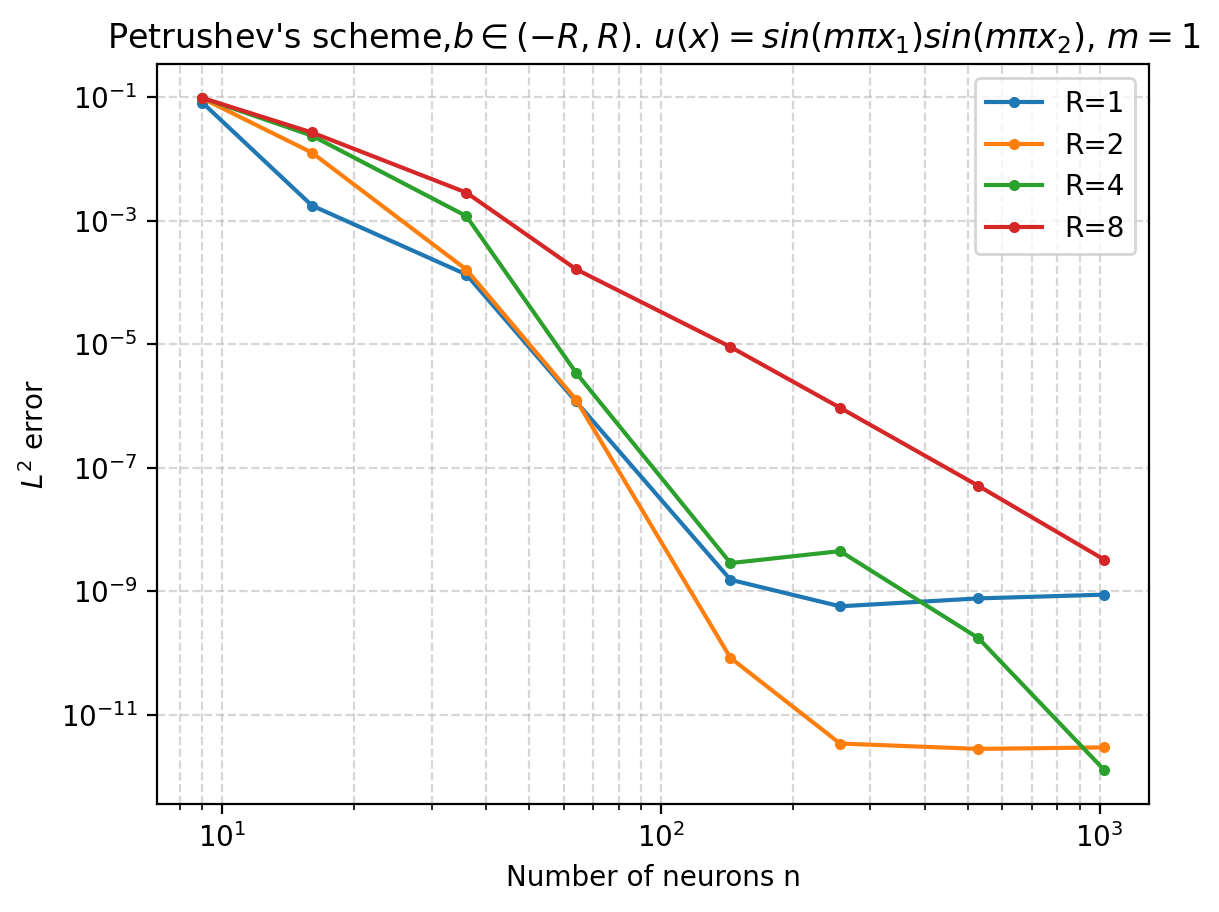

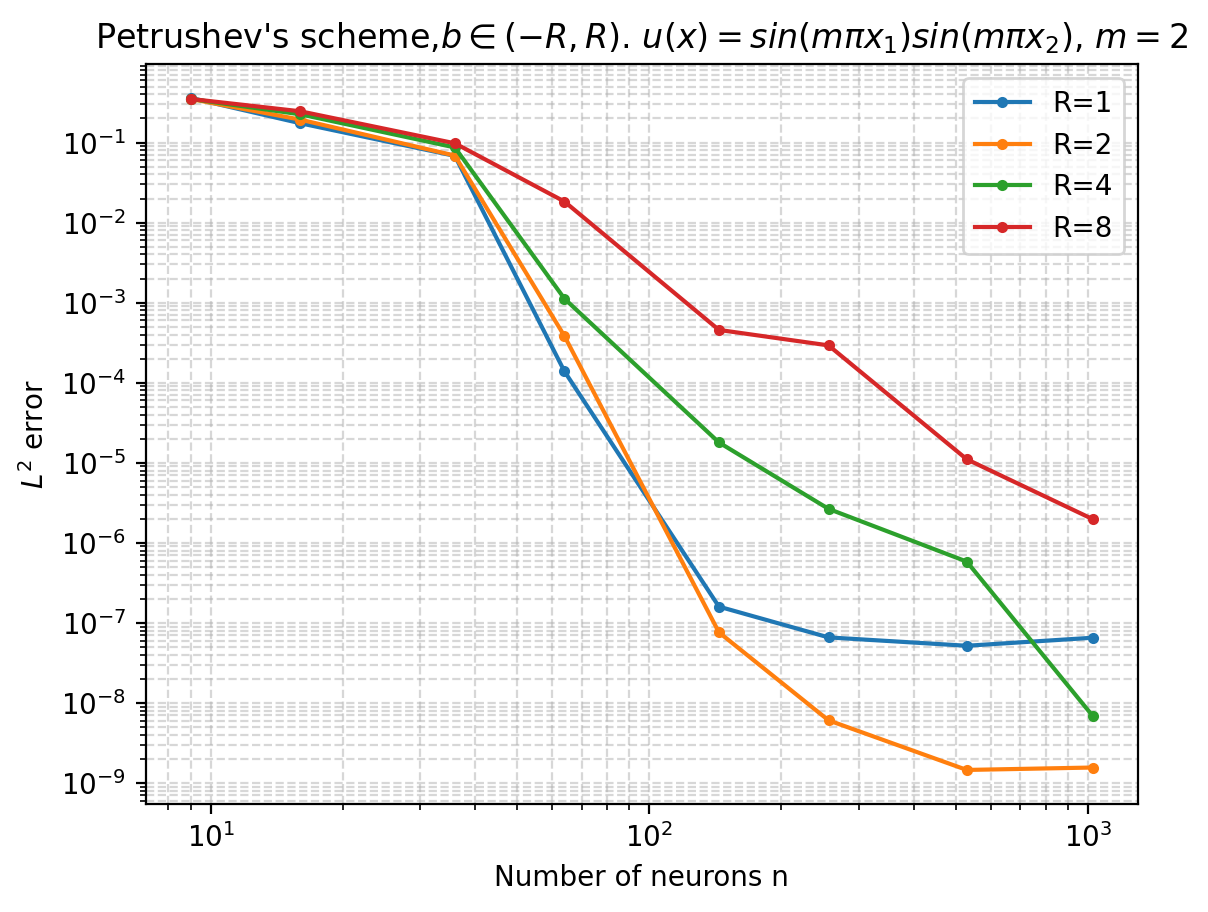

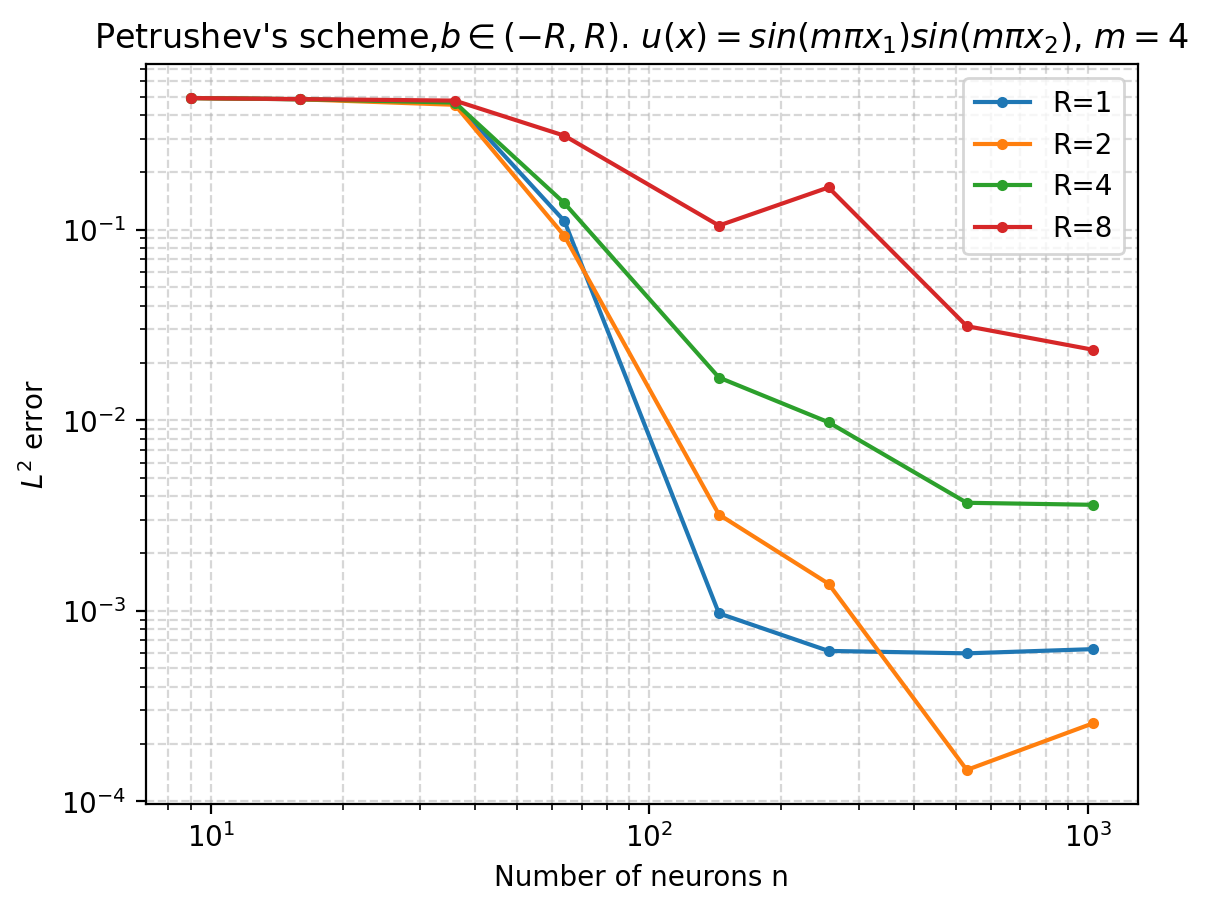

In [89]:

def run_experiment_2d(m1,m2): 

    def target(x): 
        return torch.sin(m1 * pi * x[:,0:1]) * torch.sin(m2 * pi * x[:,1:2])

    weights, integration_points = PiecewiseGQ2D_weights_points(Nx = 50, order = 2,l_point = (0,0), r_point = (1,1))

    exponent = 10
    exponent_list = [i for i in range(3,exponent+1)]
    neuron_num_list = [2**i for i in exponent_list]
    save = True 

    # x = torch.linspace(0,1,50)
    # X1, X2 = torch.meshgrid(x,x, indexing='ij')
    # x_train = torch.concat([X1.reshape(-1,1), X2.reshape(-1,1)], dim=1)
    # weights = (1/x_train.size(0) * torch.ones(x_train.size(0),1) )**2 
    # integration_points = x_train 

    plt.figure(dpi = 200)
    R_m_list = [1,2,4,8]
    for R_m in R_m_list:  
        actual_neuron_num_list = []
        mean_err_l2_list = [] 
        for n in neuron_num_list : 
            trial_num = 1  # 40 
            err_l2_trial = torch.zeros(trial_num) 
            for trial in range(trial_num):
                my_model = model_tanh(2, n, 1).to(device) 
                my_model = initialize_w_b_petrushev(my_model, R_m = R_m) 
                # my_model = initialize_w_b_uniform(my_model, R_m=R_m) 
                sol = minimize_linear_layer_least_square(my_model,target,weights, integration_points, solver="direct")
                my_model.fc2.weight.data[0,:] = sol[:]

                with torch.no_grad():
                    nn_func_values = my_model(integration_points)
                target_values = target(integration_points) 
                diff_sqrd = (nn_func_values - target_values)**2
                err_l2 = ( weights.t() @ diff_sqrd )**0.5 
                err_l2_trial[trial] = err_l2 

            mean_err_l2 = torch.mean(err_l2_trial) 
            mean_err_l2_list.append(mean_err_l2) 
            actual_neuron_num = my_model.fc1.bias.size(0) 
            actual_neuron_num_list.append(actual_neuron_num) 
            # print("actual neuron num: ", actual_neuron_num)
        neuron_num_arr = np.array(neuron_num_list) 
        actual_neuron_num_arr = np.array(actual_neuron_num_list) 
        mean_err_l2_arr = np.array(mean_err_l2_list) 
        legend1 = f"R={R_m}" 
        title = f"Petrushev's scheme,$ b \in (-R, R)$. $u(x) = sin(m \pi x_1)sin(m \pi x_2)$, $m={m1}$"
        
        plt.plot(actual_neuron_num_arr, mean_err_l2_arr, '.-', label = legend1) 

        plt.yscale('log') 
        plt.xscale('log') 
        plt.legend() 
        plt.ylabel("$L^2$ error")
        plt.xlabel("Number of neurons n")
        plt.title(title) 
    plt.grid(True, which="both", ls="--", alpha=0.5)
    filename = "petrushev_2d_sin_m_{}_variational_R_m_{}_ls_eqn.png".format(m1,R_m)
    if save: 
        plt.savefig(filename)
    else:
        plt.show()  

for m in [1,2,4]: 
    run_experiment_2d(m,m) 